#synthetic data with different scale and texture

C:\Users\hosse\AppData\Local\Temp\ipykernel_31128\2724713189.py:196: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


FileNotFoundError: [Errno 2] No such file or directory: 'D:\\VIS2025\\BIoVisChallenges\\SSGAT\\Groundtruth\\Scale_text_synthetic\\inter_rater_euclidean_distance_error_bar_broken_axis_SCALES.png'

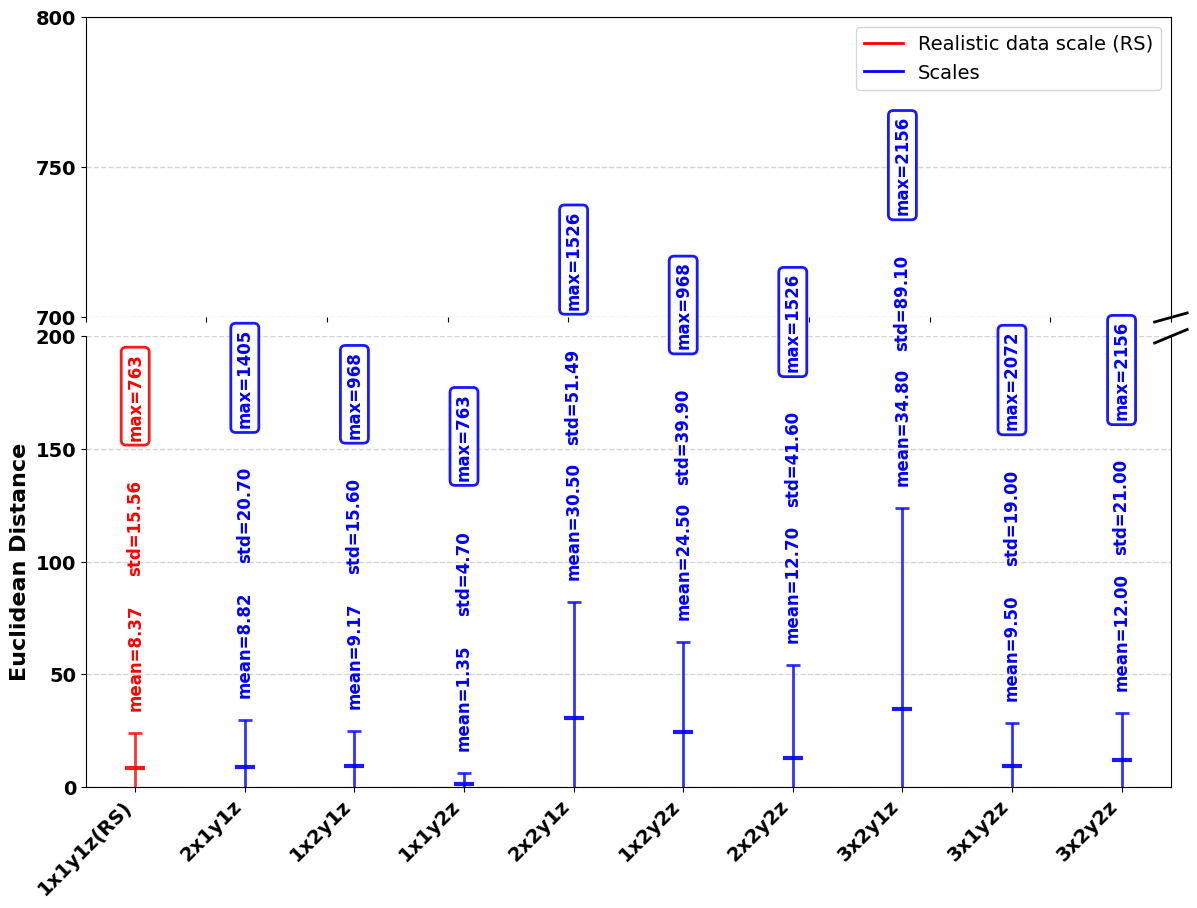

In [10]:
"""
Inter-Rater Error Bar Chart with Broken Y-Axis - SCALES ONLY
Creates error bar chart with broken y-axis for Scales only
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import os

# Configuration
BASE_DIR = r'D:\VIS2025\BIoVisChallenges\SSGAT\Groundtruth\Scale_text_synthetic'
DISTANCE_MULTIPLIER = 1  # Multiply Y-axis by 64

# Original dimensions
ORIGINAL_X = 681
ORIGINAL_Y = 344
ORIGINAL_Z = 12

# Base maximum for 1x1y1z
BASE_MAX = 761

# Function to parse scale name and extract scale factors
def parse_scale_name(name):
    """Extract scale factors from name like '2x1y1z' or '1x1y1z(RS)'"""
    import re
    # Remove (RS) or (GT) suffix if present
    name_clean = re.sub(r'\([^)]+\)', '', name).strip()
    # Extract numbers before x, y, z
    match = re.match(r'(\d+)x(\d+)y(\d+)z', name_clean)
    if match:
        return int(match.group(1)), int(match.group(2)), int(match.group(3))
    return 1, 1, 1  # Default to 1x1y1z if parsing fails

# Function to calculate maximum Y for a given scale
def calculate_max_y(scale_x, scale_y, scale_z):
    """Calculate maximum Y based on scale factors"""
    # Calculate Euclidean distance for scaled dimensions
    scaled_dist = np.sqrt((scale_x * ORIGINAL_X)**2 + (scale_y * ORIGINAL_Y)**2 + (scale_z * ORIGINAL_Z)**2)
    # Calculate Euclidean distance for base (1x1y1z)
    base_dist = np.sqrt((1 * ORIGINAL_X)**2 + (1 * ORIGINAL_Y)**2 + (1 * ORIGINAL_Z)**2)
    # Scale the maximum proportionally
    max_y = BASE_MAX * (scaled_dist / base_dist)
    return max_y

# Function to calculate maximum value for display (Euclidean distance)
def calculate_display_max(scale_x, scale_y, scale_z):
    """Calculate maximum value for display using Euclidean distance"""
    # Calculate Euclidean distance for scaled dimensions
    max_distance = np.sqrt((scale_x * ORIGINAL_X)**2 + (scale_y * ORIGINAL_Y)**2 + (scale_z * ORIGINAL_Z)**2)
    return max_distance

# Data from the results
data = {
    'Type': ['Scale', 'Scale', 'Scale', 'Scale', 'Scale', 'Scale', 'Scale', 'Scale', 'Scale', 'Scale',
             'Texture', 'Texture', 'Texture', 'Texture', 'Texture'],
    'Name': ['1x1y1z(RS)', '2x1y1z', '1x2y1z', '1x1y2z', '2x2y1z', '1x2y2z', '2x2y2z', '3x2y1z', '3x1y2z', '3x2y2z',
             'texture1', 'texture2', 'texture3', 'texture4', 'texture5'],
    
    'Mean Euclidean Distance': [8.37, 8.82, 9.17, 1.35, 30.5, 24.5, 12.7, 34.8, 9.5, 12, 3.85, 5.5, 4.11, 3.3, 2.3],
    'Std Euclidean Distance': [15.56, 20.70, 15.6, 4.7, 51.49, 39.9, 41.6, 89.1, 19.0, 21, 8.53, 10.9, 6.8, 7.5, 6.5]
}

df = pd.DataFrame(data)

# Separate scales and textures
scale_data = df[df['Type'] == 'Scale'].copy()

# Calculate maximum Y for each scale
scale_data['Max_Y'] = scale_data['Name'].apply(
    lambda name: calculate_max_y(*parse_scale_name(name))
)

# Calculate display maximum for each scale (for labeling)
scale_data['Display_Max'] = scale_data['Name'].apply(
    lambda name: calculate_display_max(*parse_scale_name(name))
)

# Create figure with broken y-axis (crop 300-600)
# Note: High values (600-800) at top, low values (0-300) at bottom
# Top part is 2/3 of bottom part height, same scale step
fig = plt.figure(figsize=(14, 10))
gs = GridSpec(2, 1, height_ratios=[2, 3], hspace=0.05)  # Top is 2/3 of bottom

# Top subplot (600 to 800) - displayed at top (high values)
ax2 = fig.add_subplot(gs[0, 0])
# Bottom subplot (0 to 300) - displayed at bottom (low values)
ax1 = fig.add_subplot(gs[1, 0])

# Y-axis break parameters
Y_BOTTOM_MAX = 200
Y_TOP_MIN = 700
Y_TOP_MAX = 800

# Calculate x positions for scales only
x_pos_scale = np.arange(len(scale_data))

# Plot scales on both axes
scale_text_positions_bottom = []
scale_text_positions_top = []
if len(scale_data) > 0:
    scale_names = scale_data['Name'].tolist()
    scale_means = (scale_data['Mean Euclidean Distance'] * DISTANCE_MULTIPLIER).tolist()
    scale_stds = (scale_data['Std Euclidean Distance'] * DISTANCE_MULTIPLIER).tolist()
    scale_display_maxes = scale_data['Display_Max'].tolist()
    scale_colors = ['red' if name == '1x1y1z(RS)' else 'blue' for name in scale_names]
    
    for i, (mean, std, color, name, display_max) in enumerate(zip(scale_means, scale_stds, scale_colors, scale_names, scale_display_maxes)):
        # Plot on bottom if value <= 300
        if mean <= Y_BOTTOM_MAX:
            ax1.errorbar(x_pos_scale[i], mean, yerr=std, fmt='none', color=color, capsize=5, capthick=2, linewidth=2, alpha=0.8)
            ax1.plot(x_pos_scale[i], mean, marker='_', color=color, markersize=15, markeredgewidth=3, alpha=0.9)
            scale_text_positions_bottom.append((x_pos_scale[i], mean, std, color, mean, display_max))
        # Plot on top if value >= 600
        elif mean >= Y_TOP_MIN:
            ax2.errorbar(x_pos_scale[i], mean, yerr=std, fmt='none', color=color, capsize=5, capthick=2, linewidth=2, alpha=0.8)
            ax2.plot(x_pos_scale[i], mean, marker='_', color=color, markersize=15, markeredgewidth=3, alpha=0.9)
            scale_text_positions_top.append((x_pos_scale[i], mean, std, color, mean, display_max))

# Use scale names and positions only
all_names = scale_data['Name'].tolist()
all_x_pos = list(x_pos_scale)

# Configure top subplot (600-800) - displayed at top (high values)
ax2.set_xticks(all_x_pos)
ax2.set_xticklabels([])  # Hide x labels on top subplot
ax2.grid(axis='y', alpha=0.530, linestyle='--', linewidth=1)
ax2.set_ylim(bottom=Y_TOP_MIN, top=Y_TOP_MAX)
ax2.spines['bottom'].set_visible(False)  # Hide bottom spine (broken axis)

# Set same scale step for both subplots (50 units per step)
tick_step = 50
ax2.set_yticks(np.arange(Y_TOP_MIN, Y_TOP_MAX + tick_step, tick_step))

# Configure bottom subplot (0-300) - displayed at bottom (low values)
ax1.set_ylabel(f'Euclidean Distance', fontsize=16, fontweight='bold')
ax1.set_xticks(all_x_pos)
ax1.set_xticklabels(all_names, rotation=45, ha='right', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.530, linestyle='--', linewidth=1)
ax1.set_ylim(bottom=0, top=Y_BOTTOM_MAX)
ax1.spines['top'].set_visible(False)  # Hide top spine (broken axis)

# Set same scale step for both subplots (50 units per step)
ax1.set_yticks(np.arange(0, Y_BOTTOM_MAX + tick_step, tick_step))

# Add broken axis indicators (diagonal lines)
d = 0.015  # Size of diagonal lines
kwargs = dict(transform=ax2.transAxes, color='k', clip_on=False, linewidth=2)
ax2.plot((1-d, 1+d), (-d, +d), **kwargs)  # Bottom-right diagonal (at bottom of top subplot)

kwargs.update(transform=ax1.transAxes)
ax1.plot((1-d, 1+d), (1-d, 1+d), **kwargs)  # Top-right diagonal (at top of bottom subplot)

# Add mean and std text vertically on top of each bar for SCALES (bottom subplot - 0-300, low values)
for i, (x_pos, mean, std, color, _, display_max) in enumerate(scale_text_positions_bottom):
    offset = Y_BOTTOM_MAX * 0.05
    text_y_base = mean + std + offset
    text_spacing = Y_BOTTOM_MAX * 0.30  # Distance between mean and std (relative to range) - increased more
    # Place mean and std vertically, one after another with proper spacing
    ax1.text(x_pos, text_y_base, f'mean={mean:.2f}', 
           ha='center', va='bottom', fontsize=12, fontweight='heavy', color=color, rotation=90)
    ax1.text(x_pos, text_y_base + text_spacing, f'std={std:.2f}', 
           ha='center', va='bottom', fontsize=12, fontweight='heavy', color=color, rotation=90)
    # Add maximum value with box on top
    max_text_y = text_y_base + text_spacing * 2
    ax1.text(x_pos, max_text_y, f'max={display_max:.0f}', 
           ha='center', va='bottom', fontsize=12, fontweight='heavy', color=color, rotation=90,
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor=color, linewidth=2))

# Add mean and std text vertically on top of each bar for SCALES (top subplot - 600-800, high values)
for i, (x_pos, mean, std, color, _, display_max) in enumerate(scale_text_positions_top):
    offset = (Y_TOP_MAX - Y_TOP_MIN) * 0.05
    text_y_base = mean + std + offset
    text_spacing = (Y_TOP_MAX - Y_TOP_MIN) * 0.30  # Distance between mean and std (relative to range) - increased more
    # Place mean and std vertically, one after another with proper spacing
    ax2.text(x_pos, text_y_base, f'mean={mean:.2f}', 
           ha='center', va='bottom', fontsize=12, fontweight='heavy', color=color, rotation=90)
    ax2.text(x_pos, text_y_base + text_spacing, f'std={std:.2f}', 
           ha='center', va='bottom', fontsize=12, fontweight='heavy', color=color, rotation=90)
    # Add maximum value with box on top
    max_text_y = text_y_base + text_spacing * 2
    ax2.text(x_pos, max_text_y, f'max={display_max:.0f}', 
           ha='center', va='bottom', fontsize=12, fontweight='heavy', color=color, rotation=90,
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor=color, linewidth=2))

# Add legend (on top subplot - ax2, high values)
legend_elements = [
    plt.Line2D([0], [0], color='red', linewidth=2, marker='_', markersize=15, label='Realistic data scale (RS)'),
    plt.Line2D([0], [0], color='blue', linewidth=2, marker='_', markersize=15, label='Scales')
]
ax2.legend(handles=legend_elements, fontsize=14, loc='upper right')
plt.setp(ax1.get_yticklabels(), fontsize=14, fontweight='bold')
plt.setp(ax2.get_yticklabels(), fontsize=14, fontweight='bold')

plt.tight_layout()

# Save plot
interrater_path = os.path.join(BASE_DIR, 'inter_rater_euclidean_distance_error_bar_broken_axis_SCALES.png')
plt.savefig(interrater_path, dpi=300, bbox_inches='tight')
print(f"✓ Inter-rater error bar chart with broken axis (SCALES) saved to: {interrater_path}")
plt.show()

# Display data summary
print("\n" + "="*70)
print("DATA SUMMARY - SCALES")
print("="*70)
print(scale_data.to_string(index=False))
print("="*70)


C:\Users\hosse\AppData\Local\Temp\ipykernel_31128\221790246.py:146: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


✓ Inter-rater error bar chart with broken axis (TEXTURES) saved to: D:\VIS2025\BIoVisChallenges\SSGAT\Groundtruth\Scale\inter_rater_euclidean_distance_error_bar_broken_axis_TEXTURES.png


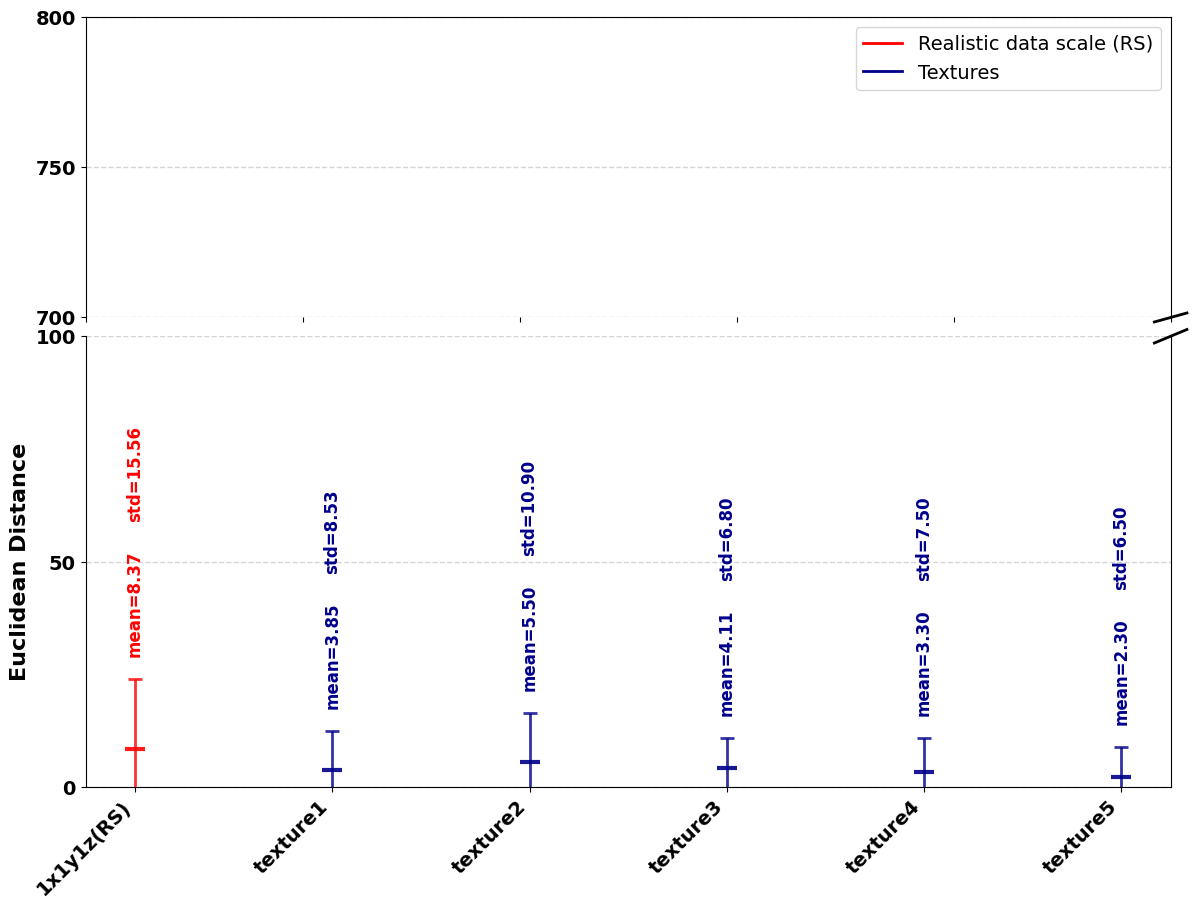


DATA SUMMARY - TEXTURES
   Type       Name  Mean Euclidean Distance  Std Euclidean Distance
  Scale 1x1y1z(RS)                     8.37                   15.56
Texture   texture1                     3.85                    8.53
Texture   texture2                     5.50                   10.90
Texture   texture3                     4.11                    6.80
Texture   texture4                     3.30                    7.50
Texture   texture5                     2.30                    6.50


In [4]:
"""
Inter-Rater Error Bar Chart with Broken Y-Axis - TEXTURES ONLY
Creates error bar chart with broken y-axis for Textures only
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import os

# Configuration
BASE_DIR = r'D:\VIS2025\BIoVisChallenges\SSGAT\Groundtruth\Scale'
DISTANCE_MULTIPLIER = 1  # Multiply Y-axis by 64

# Data from the results
data = {
    'Type': ['Scale', 'Scale', 'Scale', 'Scale', 'Scale', 'Scale', 'Scale', 'Scale', 'Scale', 'Scale',
             'Texture', 'Texture', 'Texture', 'Texture', 'Texture'],
    'Name': ['1x1y1z(RS)', '2x1y1z', '1x2y1z', '1x1y2z', '2x2y1z', '1x2y2z', '2x2y2z', '3x2y1z', '3x1y2z', '3x2y2z',
             'texture1', 'texture2', 'texture3', 'texture4', 'texture5'],
    
    'Mean Euclidean Distance': [8.37, 8.82, 9.17, 1.35, 30.5, 24.5, 12.7, 34.8, 9.5, 12, 3.85, 5.5, 4.11, 3.3, 2.3],
    'Std Euclidean Distance': [15.56, 20.70, 15.6, 4.7, 51.49, 39.9, 41.6, 89.1, 19.0, 21, 8.53, 10.9, 6.8, 7.5, 6.5]
}

df = pd.DataFrame(data)

# Get 1x1y1z(GT) from scales and textures
scale_data = df[df['Type'] == 'Scale']
texture_data = df[df['Type'] == 'Texture']

# Find 1x1y1z(GT) from scales
gt_row = scale_data[scale_data['Name'] == '1x1y1z(RS)'].copy()

# Combine: 1x1y1z(GT) first, then textures
if len(gt_row) > 0:
    texture_data = pd.concat([gt_row, texture_data], ignore_index=True)

# Create figure with broken y-axis (crop 300-600)
# Note: High values (600-800) at top, low values (0-300) at bottom
# Top part is 2/3 of bottom part height, same scale step
fig = plt.figure(figsize=(14, 10))
gs = GridSpec(2, 1, height_ratios=[2, 3], hspace=0.05)  # Top is 2/3 of bottom

# Top subplot (600 to 800) - displayed at top (high values)
ax2 = fig.add_subplot(gs[0, 0])
# Bottom subplot (0 to 300) - displayed at bottom (low values)
ax1 = fig.add_subplot(gs[1, 0])

# Y-axis break parameters
Y_BOTTOM_MAX = 100
Y_TOP_MIN = 700
Y_TOP_MAX = 800

# Calculate x positions for textures only
x_pos_texture = np.arange(len(texture_data))

# Plot textures on both axes
texture_text_positions_bottom = []
texture_text_positions_top = []
if len(texture_data) > 0:
    texture_names = texture_data['Name'].tolist()
    texture_means = (texture_data['Mean Euclidean Distance'] * DISTANCE_MULTIPLIER).tolist()
    texture_stds = (texture_data['Std Euclidean Distance'] * DISTANCE_MULTIPLIER).tolist()
    # Color: red for 1x1y1z(GT), darkblue for textures
    texture_colors = ['red' if name == '1x1y1z(RS)' else 'darkblue' for name in texture_names]
    
    for i, (mean, std, color, name) in enumerate(zip(texture_means, texture_stds, texture_colors, texture_names)):
        # Plot on bottom if value <= 300
        if mean <= Y_BOTTOM_MAX:
            ax1.errorbar(x_pos_texture[i], mean, yerr=std, fmt='none', color=color, capsize=5, capthick=2, linewidth=2, alpha=0.8)
            ax1.plot(x_pos_texture[i], mean, marker='_', color=color, markersize=15, markeredgewidth=3, alpha=0.9)
            texture_text_positions_bottom.append((x_pos_texture[i], mean, std, color, mean))
        # Plot on top if value >= 600
        elif mean >= Y_TOP_MIN:
            ax2.errorbar(x_pos_texture[i], mean, yerr=std, fmt='none', color=color, capsize=5, capthick=2, linewidth=2, alpha=0.8)
            ax2.plot(x_pos_texture[i], mean, marker='_', color=color, markersize=15, markeredgewidth=3, alpha=0.9)
            texture_text_positions_top.append((x_pos_texture[i], mean, std, color, mean))

# Use texture names and positions only
all_names = texture_data['Name'].tolist()
all_x_pos = list(x_pos_texture)

# Configure top subplot (600-800) - displayed at top (high values)
ax2.set_xticks(all_x_pos)
ax2.set_xticklabels([])  # Hide x labels on top subplot
ax2.grid(axis='y', alpha=0.530, linestyle='--', linewidth=1)
ax2.set_ylim(bottom=Y_TOP_MIN, top=Y_TOP_MAX)
ax2.spines['bottom'].set_visible(False)  # Hide bottom spine (broken axis)

# Set same scale step for both subplots (50 units per step)
tick_step = 50
ax2.set_yticks(np.arange(Y_TOP_MIN, Y_TOP_MAX + tick_step, tick_step))

# Configure bottom subplot (0-300) - displayed at bottom (low values)
ax1.set_ylabel(f'Euclidean Distance', fontsize=16, fontweight='bold')
ax1.set_xticks(all_x_pos)
ax1.set_xticklabels(all_names, rotation=45, ha='right', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.530, linestyle='--', linewidth=1)
ax1.set_ylim(bottom=0, top=Y_BOTTOM_MAX)
ax1.spines['top'].set_visible(False)  # Hide top spine (broken axis)

# Set same scale step for both subplots (50 units per step)
ax1.set_yticks(np.arange(0, Y_BOTTOM_MAX + tick_step, tick_step))

# Add broken axis indicators (diagonal lines)
d = 0.015  # Size of diagonal lines
kwargs = dict(transform=ax2.transAxes, color='k', clip_on=False, linewidth=2)
ax2.plot((1-d, 1+d), (-d, +d), **kwargs)  # Bottom-right diagonal (at bottom of top subplot)

kwargs.update(transform=ax1.transAxes)
ax1.plot((1-d, 1+d), (1-d, 1+d), **kwargs)  # Top-right diagonal (at top of bottom subplot)

# Add mean and std text vertically on top of each bar for TEXTURES (bottom subplot - 0-300, low values)
for x_pos, mean, std, color, _ in texture_text_positions_bottom:
    offset = Y_BOTTOM_MAX * 0.05
    text_y_base = mean + std + offset
    text_spacing = Y_BOTTOM_MAX * 0.30  # Distance between mean and std (relative to range) - increased more
    # Place mean and std vertically, one after another with proper spacing
    ax1.text(x_pos, text_y_base, f'mean={mean:.2f}', 
           ha='center', va='bottom', fontsize=12, fontweight='heavy', color=color, rotation=90)
    ax1.text(x_pos, text_y_base + text_spacing, f'std={std:.2f}', 
           ha='center', va='bottom', fontsize=12, fontweight='heavy', color=color, rotation=90)

# Add mean and std text vertically on top of each bar for TEXTURES (top subplot - 600-800, high values)
for x_pos, mean, std, color, _ in texture_text_positions_top:
    offset = (Y_TOP_MAX - Y_TOP_MIN) * 0.05
    text_y_base = mean + std + offset
    text_spacing = (Y_TOP_MAX - Y_TOP_MIN) * 0.30  # Distance between mean and std (relative to range) - increased more
    # Place mean and std vertically, one after another with proper spacing
    ax2.text(x_pos, text_y_base, f'mean={mean:.2f}', 
           ha='center', va='bottom', fontsize=12, fontweight='heavy', color=color, rotation=90)
    ax2.text(x_pos, text_y_base + text_spacing, f'std={std:.2f}', 
           ha='center', va='bottom', fontsize=12, fontweight='heavy', color=color, rotation=90)

# Add legend (on top subplot - ax2, high values)
legend_elements = [
    plt.Line2D([0], [0], color='red', linewidth=2, marker='_', markersize=15, label='Realistic data scale (RS)'),
    plt.Line2D([0], [0], color='darkblue', linewidth=2, marker='_', markersize=15, label='Textures')
]
ax2.legend(handles=legend_elements, fontsize=14, loc='upper right')
plt.setp(ax1.get_yticklabels(), fontsize=14, fontweight='bold')
plt.setp(ax2.get_yticklabels(), fontsize=14, fontweight='bold')

plt.tight_layout()

# Save plot
interrater_path = os.path.join(BASE_DIR, 'inter_rater_euclidean_distance_error_bar_broken_axis_TEXTURES.png')
plt.savefig(interrater_path, dpi=300, bbox_inches='tight')
print(f"✓ Inter-rater error bar chart with broken axis (TEXTURES) saved to: {interrater_path}")
plt.show()

# Display data summary
print("\n" + "="*70)
print("DATA SUMMARY - TEXTURES")
print("="*70)
print(texture_data.to_string(index=False))
print("="*70)


In [ ]:
"""
Inter-Rater Error Bar Chart with Broken Y-Axis - SCALES ONLY
Creates error bar chart with broken y-axis for Scales only
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import os

# Configuration
BASE_DIR = r'D:\VIS2025\BIoVisChallenges\SSGAT\Groundtruth\Scale_text_synthetic'
DISTANCE_MULTIPLIER = 1  # Multiply Y-axis by 64

# Original dimensions
ORIGINAL_X = 681
ORIGINAL_Y = 344
ORIGINAL_Z = 12

# Base maximum for 1x1y1z
BASE_MAX = 761

# Function to parse scale name and extract scale factors
def parse_scale_name(name):
    """Extract scale factors from name like '2x1y1z' or '1x1y1z(RS)'"""
    import re
    # Remove (RS) or (GT) suffix if present
    name_clean = re.sub(r'\([^)]+\)', '', name).strip()
    # Extract numbers before x, y, z
    match = re.match(r'(\d+)x(\d+)y(\d+)z', name_clean)
    if match:
        return int(match.group(1)), int(match.group(2)), int(match.group(3))
    return 1, 1, 1  # Default to 1x1y1z if parsing fails

# Function to calculate maximum Y for a given scale
def calculate_max_y(scale_x, scale_y, scale_z):
    """Calculate maximum Y based on scale factors"""
    # Calculate Euclidean distance for scaled dimensions
    scaled_dist = np.sqrt((scale_x * ORIGINAL_X)**2 + (scale_y * ORIGINAL_Y)**2 + (scale_z * ORIGINAL_Z)**2)
    # Calculate Euclidean distance for base (1x1y1z)
    base_dist = np.sqrt((1 * ORIGINAL_X)**2 + (1 * ORIGINAL_Y)**2 + (1 * ORIGINAL_Z)**2)
    # Scale the maximum proportionally
    max_y = BASE_MAX * (scaled_dist / base_dist)
    return max_y

# Data from the results
data = {
    'Type': ['Scale', 'Scale', 'Scale', 'Scale', 'Scale', 'Scale', 'Scale', 'Scale', 'Scale', 'Scale',
             'Texture', 'Texture', 'Texture', 'Texture', 'Texture'],
    'Name': ['1x1y1z(RS)', '2x1y1z', '1x2y1z', '1x1y2z', '2x2y1z', '1x2y2z', '2x2y2z', '3x2y1z', '3x1y2z', '3x2y2z',
             'texture1', 'texture2', 'texture3', 'texture4', 'texture5'],
    
    'Mean Euclidean Distance': [8.37, 8.82, 9.17, 1.35, 30.5, 24.5, 12.7, 34.8, 9.5, 12, 3.85, 5.5, 4.11, 3.3, 2.3],
    'Std Euclidean Distance': [15.56, 20.70, 15.6, 4.7, 51.49, 39.9, 41.6, 89.1, 19.0, 21, 8.53, 10.9, 6.8, 7.5, 6.5]
}

df = pd.DataFrame(data)

# Separate scales and textures
scale_data = df[df['Type'] == 'Scale'].copy()

# Calculate maximum Y for each scale
scale_data['Max_Y'] = scale_data['Name'].apply(
    lambda name: calculate_max_y(*parse_scale_name(name))
)

# Create figure with broken y-axis (crop 300-600)
# Note: High values (600-800) at top, low values (0-300) at bottom
# Top part is 2/3 of bottom part height, same scale step
fig = plt.figure(figsize=(14, 10))
gs = GridSpec(2, 1, height_ratios=[2, 3], hspace=0.05)  # Top is 2/3 of bottom

# Top subplot (600 to 800) - displayed at top (high values)
ax2 = fig.add_subplot(gs[0, 0])
# Bottom subplot (0 to 300) - displayed at bottom (low values)
ax1 = fig.add_subplot(gs[1, 0])

# Y-axis break parameters
Y_BOTTOM_MAX = 200
Y_TOP_MIN = 700
Y_TOP_MAX = 800

# Calculate x positions for scales only
x_pos_scale = np.arange(len(scale_data))

# Plot scales on both axes
scale_text_positions_bottom = []
scale_text_positions_top = []
if len(scale_data) > 0:
    scale_names = scale_data['Name'].tolist()
    scale_means = (scale_data['Mean Euclidean Distance'] * DISTANCE_MULTIPLIER).tolist()
    scale_stds = (scale_data['Std Euclidean Distance'] * DISTANCE_MULTIPLIER).tolist()
    scale_colors = ['red' if name == '1x1y1z(RS)' else 'blue' for name in scale_names]
    
    for i, (mean, std, color, name) in enumerate(zip(scale_means, scale_stds, scale_colors, scale_names)):
        # Plot on bottom if value <= 300
        if mean <= Y_BOTTOM_MAX:
            ax1.errorbar(x_pos_scale[i], mean, yerr=std, fmt='none', color=color, capsize=5, capthick=2, linewidth=2, alpha=0.8)
            ax1.plot(x_pos_scale[i], mean, marker='_', color=color, markersize=15, markeredgewidth=3, alpha=0.9)
            scale_text_positions_bottom.append((x_pos_scale[i], mean, std, color, mean))
        # Plot on top if value >= 600
        elif mean >= Y_TOP_MIN:
            ax2.errorbar(x_pos_scale[i], mean, yerr=std, fmt='none', color=color, capsize=5, capthick=2, linewidth=2, alpha=0.8)
            ax2.plot(x_pos_scale[i], mean, marker='_', color=color, markersize=15, markeredgewidth=3, alpha=0.9)
            scale_text_positions_top.append((x_pos_scale[i], mean, std, color, mean))

# Use scale names and positions only
all_names = scale_data['Name'].tolist()
all_x_pos = list(x_pos_scale)

# Configure top subplot (600-800) - displayed at top (high values)
ax2.set_xticks(all_x_pos)
ax2.set_xticklabels([])  # Hide x labels on top subplot
ax2.grid(axis='y', alpha=0.530, linestyle='--', linewidth=1)
ax2.set_ylim(bottom=Y_TOP_MIN, top=Y_TOP_MAX)
ax2.spines['bottom'].set_visible(False)  # Hide bottom spine (broken axis)

# Set same scale step for both subplots (50 units per step)
tick_step = 50
ax2.set_yticks(np.arange(Y_TOP_MIN, Y_TOP_MAX + tick_step, tick_step))

# Configure bottom subplot (0-300) - displayed at bottom (low values)
ax1.set_ylabel(f'Euclidean Distance', fontsize=16, fontweight='bold')
ax1.set_xticks(all_x_pos)
ax1.set_xticklabels(all_names, rotation=45, ha='right', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.530, linestyle='--', linewidth=1)
ax1.set_ylim(bottom=0, top=Y_BOTTOM_MAX)
ax1.spines['top'].set_visible(False)  # Hide top spine (broken axis)

# Set same scale step for both subplots (50 units per step)
ax1.set_yticks(np.arange(0, Y_BOTTOM_MAX + tick_step, tick_step))

# Add broken axis indicators (diagonal lines)
d = 0.015  # Size of diagonal lines
kwargs = dict(transform=ax2.transAxes, color='k', clip_on=False, linewidth=2)
ax2.plot((1-d, 1+d), (-d, +d), **kwargs)  # Bottom-right diagonal (at bottom of top subplot)

kwargs.update(transform=ax1.transAxes)
ax1.plot((1-d, 1+d), (1-d, 1+d), **kwargs)  # Top-right diagonal (at top of bottom subplot)

# Add mean and std text vertically on top of each bar for SCALES (bottom subplot - 0-300, low values)
for i, (x_pos, mean, std, color, _) in enumerate(scale_text_positions_bottom):
    offset = Y_BOTTOM_MAX * 0.05
    text_y_base = mean + std + offset
    text_spacing = Y_BOTTOM_MAX * 0.30  # Distance between mean and std (relative to range) - increased more
    # Place mean and std vertically, one after another with proper spacing
    ax1.text(x_pos, text_y_base, f'mean={mean:.2f}', 
           ha='center', va='bottom', fontsize=12, fontweight='heavy', color=color, rotation=90)
    ax1.text(x_pos, text_y_base + text_spacing, f'std={std:.2f}', 
           ha='center', va='bottom', fontsize=12, fontweight='heavy', color=color, rotation=90)

# Add mean and std text vertically on top of each bar for SCALES (top subplot - 600-800, high values)
for i, (x_pos, mean, std, color, _) in enumerate(scale_text_positions_top):
    offset = (Y_TOP_MAX - Y_TOP_MIN) * 0.05
    text_y_base = mean + std + offset
    text_spacing = (Y_TOP_MAX - Y_TOP_MIN) * 0.30  # Distance between mean and std (relative to range) - increased more
    # Place mean and std vertically, one after another with proper spacing
    ax2.text(x_pos, text_y_base, f'mean={mean:.2f}', 
           ha='center', va='bottom', fontsize=12, fontweight='heavy', color=color, rotation=90)
    ax2.text(x_pos, text_y_base + text_spacing, f'std={std:.2f}', 
           ha='center', va='bottom', fontsize=12, fontweight='heavy', color=color, rotation=90)

# Add legend (on top subplot - ax2, high values)
legend_elements = [
    plt.Line2D([0], [0], color='red', linewidth=2, marker='_', markersize=15, label='Realistic data scale (RS)'),
    plt.Line2D([0], [0], color='blue', linewidth=2, marker='_', markersize=15, label='Scales')
]
ax2.legend(handles=legend_elements, fontsize=14, loc='upper right')
plt.setp(ax1.get_yticklabels(), fontsize=14, fontweight='bold')
plt.setp(ax2.get_yticklabels(), fontsize=14, fontweight='bold')

plt.tight_layout()

# Save plot
interrater_path = os.path.join(BASE_DIR, 'inter_rater_euclidean_distance_error_bar_broken_axis_SCALES.png')
plt.savefig(interrater_path, dpi=300, bbox_inches='tight')
print(f"✓ Inter-rater error bar chart with broken axis (SCALES) saved to: {interrater_path}")
plt.show()

# Display data summary
print("\n" + "="*70)
print("DATA SUMMARY - SCALES")
print("="*70)
print(scale_data.to_string(index=False))
print("="*70)
